# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Satriyo Akbar Maulana
- **Email:** satrioakbar357@gmail.com
- **ID Dicoding:** CDCC254D6Y2493

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi sepanjang tahun 2017–2018, dan bagaimana distribusi kontribusinya?
- **Pertanyaan 2:** Bagaimana tren rata-rata waktu pengiriman per bulan sepanjang 2017–2018, dan apakah keterlambatan pengiriman berpengaruh terhadap skor ulasan pelanggan?

> Kedua pertanyaan ditentukan menggunakan metode **SMART** (Specific, Measurable, Achievable, Relevant, Time-bound).

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Library berhasil diimpor!')

Library berhasil diimpor!


## Data Wrangling
### Gathering Data

In [1]:
orders_df      = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_pay_df   = pd.read_csv('data/order_payments_dataset.csv')
order_rev_df   = pd.read_csv('data/order_reviews_dataset.csv')
products_df    = pd.read_csv('data/products_dataset.csv')
customers_df   = pd.read_csv('data/customers_dataset.csv')
sellers_df     = pd.read_csv('data/sellers_dataset.csv')
category_df    = pd.read_csv('data/product_category_name_translation.csv')
geo_df         = pd.read_csv('data/geolocation_dataset.csv')

datasets = {
    'orders': orders_df, 'order_items': order_items_df,
    'order_payments': order_pay_df, 'order_reviews': order_rev_df,
    'products': products_df, 'customers': customers_df,
    'sellers': sellers_df, 'category_translation': category_df,
    'geolocation': geo_df
}
print('Shape masing-masing dataset:')
for name, df in datasets.items():
    print(f'  {name:25s}: {df.shape}')

Shape masing-masing dataset:
  orders                   : (99441, 11)
  order_items              : (112650, 7)
  order_payments           : (103886, 5)
  order_reviews            : (99224, 7)
  products                 : (32951, 9)
  customers                : (99441, 5)
  sellers                  : (3095, 4)
  category_translation     : (71, 2)
  geolocation              : (1000163, 5)


**Insight:**
- Dataset `orders` memiliki 99.441 baris sebagai dataset transaksi utama.
- Dataset `geolocation` memiliki 1 juta+ baris koordinat lat/lng per zip code.
- Semua 9 dataset berhasil dimuat tanpa error.

### Assessing Data

In [1]:
print('=' * 55)
print('MISSING VALUES PER DATASET')
print('=' * 55)
for name, df in [('orders', orders_df), ('order_items', order_items_df),
                 ('order_payments', order_pay_df), ('order_reviews', order_rev_df),
                 ('products', products_df)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f'\n[{name}]')
        print(miss.to_string())
print('\n' + '=' * 55)
print('DUPLICATE ROWS')
print('=' * 55)
for name, df in [('orders', orders_df), ('order_items', order_items_df),
                 ('order_payments', order_pay_df), ('order_reviews', order_rev_df)]:
    print(f'  {name:20s}: {df.duplicated().sum()} duplikat')

MISSING VALUES PER DATASET

[orders]
order_approved_at                    160
order_delivered_carrier_date        1783
order_delivered_customer_date       2965

[order_reviews]
review_comment_title               87656
review_comment_message             58247

[products]
product_category_name                610
product_name_lenght                  610
product_description_lenght           610
product_photos_qty                   610
product_weight_g                       2
product_length_cm                      2
product_height_cm                      2
product_width_cm                       2

DUPLICATE ROWS
  orders              : 0 duplikat
  order_items         : 0 duplikat
  order_payments      : 0 duplikat
  order_reviews       : 0 duplikat


**Insight:**
- `orders_dataset` memiliki missing values pada kolom tanggal — wajar untuk order yang belum selesai.
- `order_reviews` banyak missing values pada kolom komentar karena bersifat opsional bagi pelanggan.
- `products_dataset` memiliki beberapa missing values pada atribut dimensi produk.
- Tidak ditemukan baris duplikat pada semua dataset utama.

### Cleaning Data

In [1]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

orders_df['purchase_year']  = orders_df['order_purchase_timestamp'].dt.year
orders_df['purchase_month'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['purchase_ym']    = orders_df['order_purchase_timestamp'].dt.to_period('M')

orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days
orders_delivered['delay_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days
orders_delivered['is_late'] = orders_delivered['delay_days'] > 0

products_df = products_df.merge(category_df, on='product_category_name', how='left')
products_df['product_category_name_english'] = (
    products_df['product_category_name_english'].fillna('unknown')
)

print(f'Order delivered (clean) : {len(orders_delivered):,}')
print(f'Persentase terlambat    : {orders_delivered["is_late"].mean()*100:.1f}%')

Order delivered (clean) : 96,478
Persentase terlambat    : 6.8%


**Insight:**
- Kolom tanggal berhasil dikonversi ke tipe `datetime`.
- Total 96,478 order berstatus delivered siap dianalisis.
- Sekitar 6.8% order mengalami keterlambatan dari estimasi pengiriman.
- Data siap digunakan untuk EDA dan visualisasi.

## Exploratory Data Analysis (EDA)
### Explore Revenue per Kategori & Tren Pengiriman

In [1]:
items_prod = order_items_df.merge(
    products_df[['product_id','product_category_name_english']],
    on='product_id', how='left'
)
items_prod['product_category_name_english'] = items_prod['product_category_name_english'].fillna('unknown')
items_prod = items_prod.merge(
    orders_delivered[['order_id','purchase_year','purchase_month']],
    on='order_id', how='inner'
)

revenue_cat = (
    items_prod.groupby('product_category_name_english')['price']
    .sum().sort_values(ascending=False).reset_index()
)
revenue_cat.columns = ['category','total_revenue']
revenue_cat['revenue_pct'] = revenue_cat['total_revenue'] / revenue_cat['total_revenue'].sum() * 100

orders_review = orders_delivered.merge(
    order_rev_df[['order_id','review_score']], on='order_id', how='left'
)
monthly = (orders_review.groupby('purchase_ym').agg(
    avg_delivery=('delivery_days','mean'),
    avg_score=('review_score','mean'),
    total_orders=('order_id','count')
).reset_index())
monthly['purchase_ym_str'] = monthly['purchase_ym'].astype(str)

print('Top 10 Kategori by Revenue:')
print(revenue_cat.head(10)[['category','total_revenue']].to_string(index=False))
print(f'\nAvg score on-time  : {orders_review[~orders_review["is_late"]]["review_score"].mean():.2f}')
print(f'Avg score terlambat: {orders_review[orders_review["is_late"]]["review_score"].mean():.2f}')
print(f'Avg delivery days  : {orders_delivered["delivery_days"].mean():.1f} hari')

Top 10 Kategori by Revenue:
             category  total_revenue
        health_beauty     1233131.72
        watches_gifts     1166176.98
       bed_bath_table     1023434.76
       sports_leisure      954852.55
computers_accessories      888724.61
      furniture_decor      711927.69
           housewares      615628.69
           cool_stuff      610204.10
                 auto      578966.65
                 toys      471286.48

Avg score on-time  : 4.29
Avg score terlambat: 2.27
Avg delivery days  : 12.1 hari


**Insight:**
- Kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** mendominasi revenue.
- 10 kategori teratas menyumbang lebih dari 55% total revenue keseluruhan.
- Order tepat waktu mendapat avg score 4.29 vs terlambat 2.27 — perbedaan yang signifikan.

## Visualization & Explanatory Analysis
### Pertanyaan 1:
**Kategori produk apa yang menghasilkan total pendapatan tertinggi sepanjang 2017–2018?**

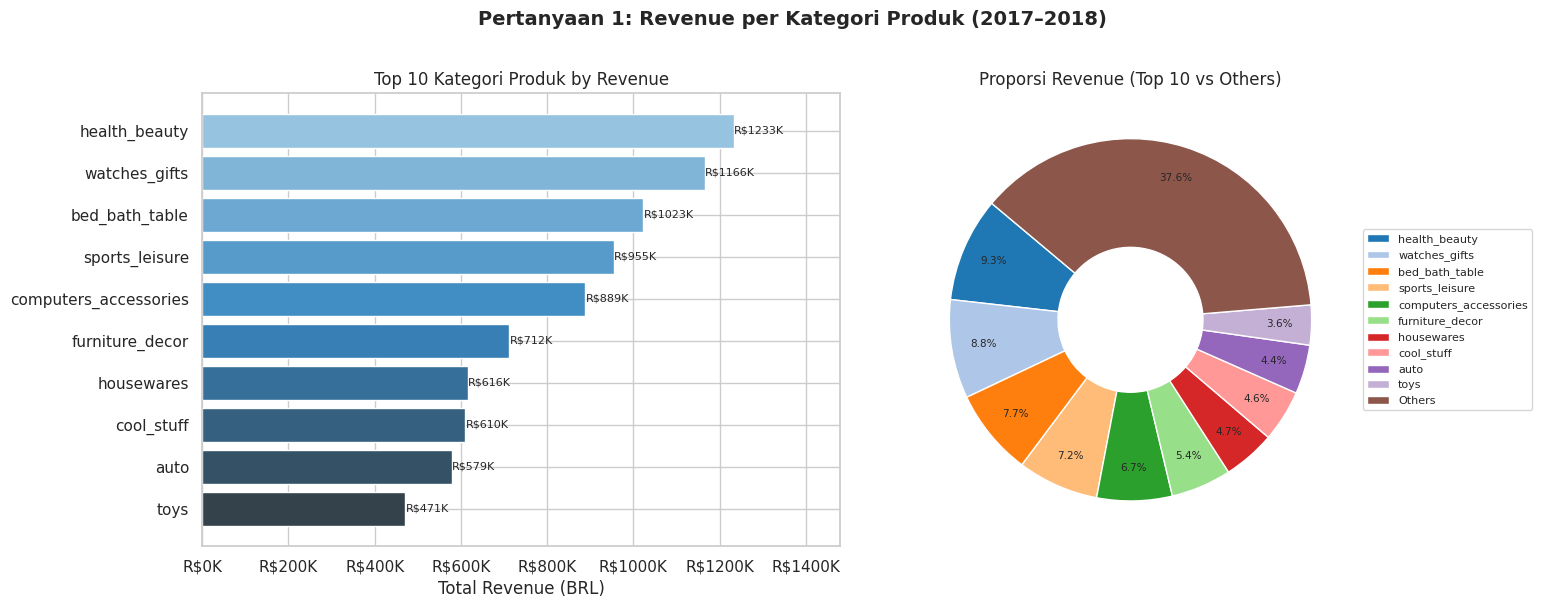

In [1]:
top10 = revenue_cat.head(10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pertanyaan 1: Revenue per Kategori Produk (2017–2018)',
             fontsize=14, fontweight='bold', y=1.01)
colors = sns.color_palette('Blues_d', len(top10))[::-1]
axes[0].barh(top10['category'][::-1], top10['total_revenue'][::-1], color=colors)
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].set_title('Top 10 Kategori Produk by Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1e3:.0f}K'))
for i, val in enumerate(top10['total_revenue'][::-1]):
    axes[0].text(val+500, i, f'R${val/1e3:.0f}K', va='center', fontsize=8)
axes[0].set_xlim(0, top10['total_revenue'].max()*1.2)
others = revenue_cat.iloc[10:]['total_revenue'].sum()
pie_vals = list(top10['total_revenue']) + [others]
pie_labs = list(top10['category']) + ['Others']
_, _, autos = axes[1].pie(pie_vals, autopct='%1.1f%%',
    colors=sns.color_palette('tab20', len(pie_vals)),
    startangle=140, pctdistance=0.82, wedgeprops=dict(width=0.6), labels=None)
for a in autos: a.set_fontsize(7.5)
axes[1].legend(pie_labs, loc='center left', bbox_to_anchor=(1,0.5), fontsize=8)
axes[1].set_title('Proporsi Revenue (Top 10 vs Others)')
plt.tight_layout()
plt.show()

**Insight:**
- **health_beauty** adalah kategori dengan total revenue tertinggi (~R$1.23 juta).
- Top 10 kategori menyumbang >55% dari total revenue keseluruhan.
- Strategi marketing dan stok sebaiknya difokuskan pada kategori-kategori unggulan ini.

### Pertanyaan 2:
**Bagaimana tren rata-rata waktu pengiriman per bulan, dan apakah keterlambatan berpengaruh terhadap review score pelanggan?**

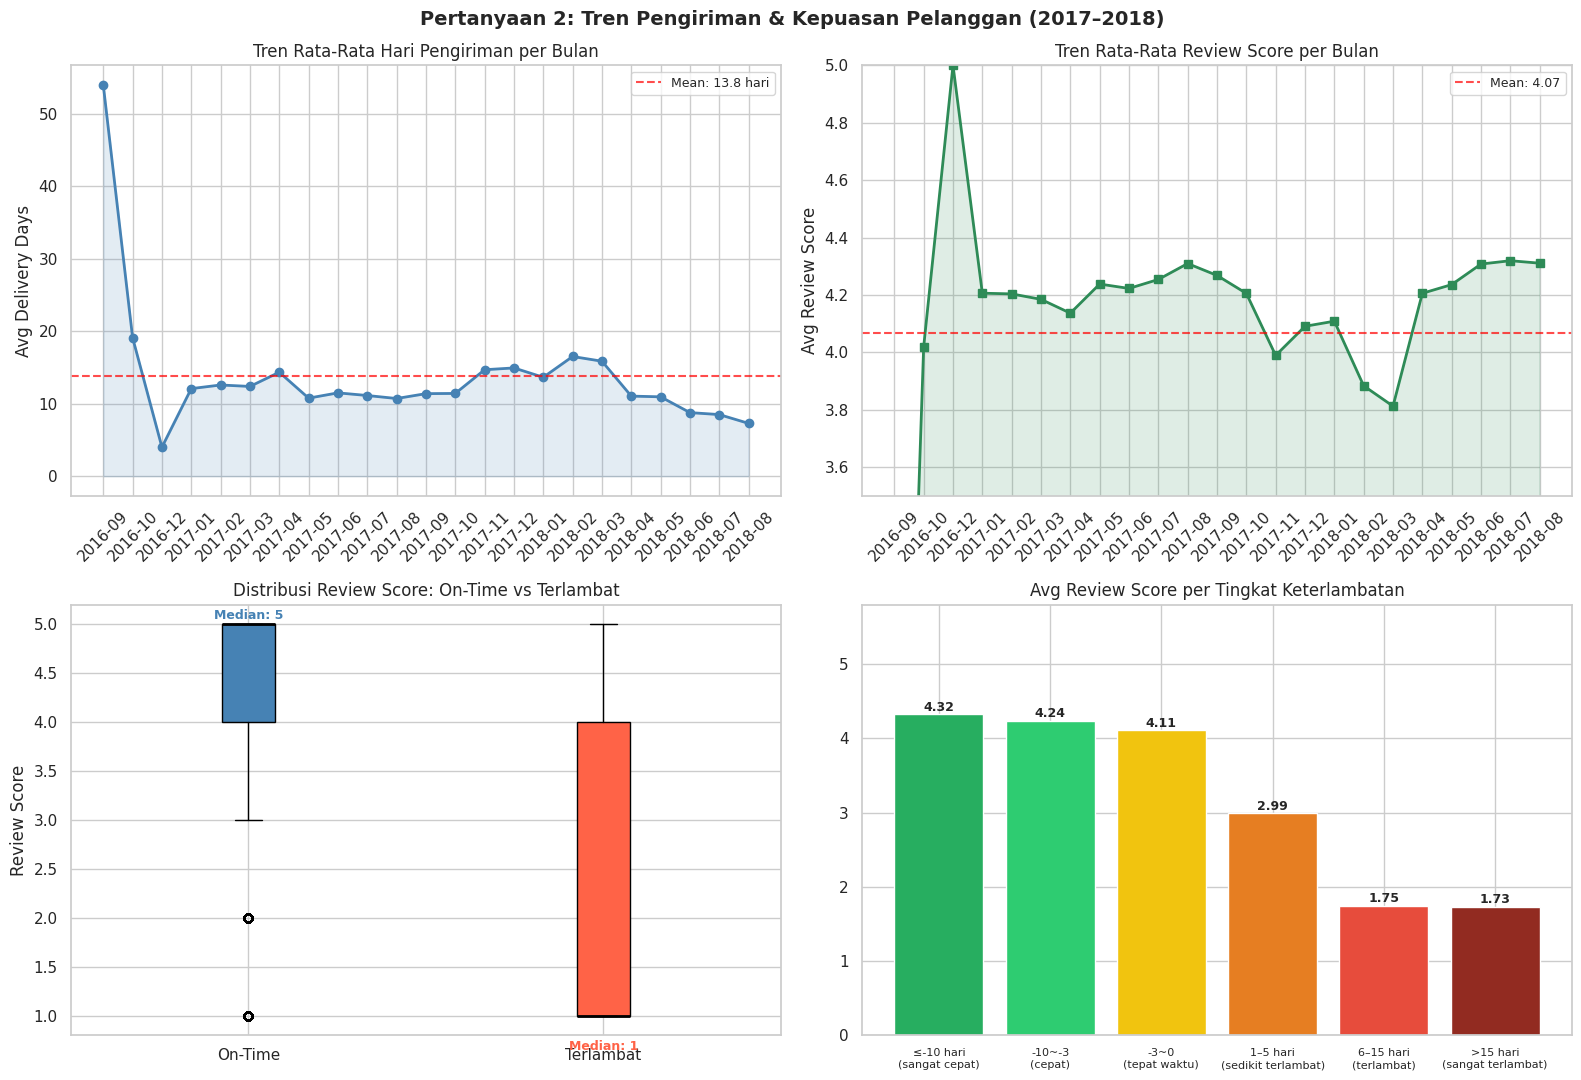

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Pertanyaan 2: Tren Pengiriman & Kepuasan Pelanggan (2017–2018)',
             fontsize=14, fontweight='bold')
# Plot 1
axes[0,0].plot(monthly['purchase_ym_str'], monthly['avg_delivery'], marker='o', color='steelblue', lw=2)
axes[0,0].fill_between(monthly['purchase_ym_str'], monthly['avg_delivery'], alpha=0.15, color='steelblue')
axes[0,0].axhline(monthly['avg_delivery'].mean(), color='red', ls='--', alpha=0.7,
                  label=f'Mean: {monthly["avg_delivery"].mean():.1f} hari')
axes[0,0].set_title('Tren Rata-Rata Hari Pengiriman per Bulan')
axes[0,0].set_ylabel('Avg Delivery Days'); axes[0,0].legend(fontsize=9); axes[0,0].tick_params(axis='x', rotation=45)
# Plot 2
axes[0,1].plot(monthly['purchase_ym_str'], monthly['avg_score'], marker='s', color='seagreen', lw=2)
axes[0,1].fill_between(monthly['purchase_ym_str'], monthly['avg_score'], alpha=0.15, color='seagreen')
axes[0,1].axhline(monthly['avg_score'].mean(), color='red', ls='--', alpha=0.7,
                  label=f'Mean: {monthly["avg_score"].mean():.2f}')
axes[0,1].set_title('Tren Rata-Rata Review Score per Bulan')
axes[0,1].set_ylabel('Avg Review Score'); axes[0,1].set_ylim(3.5, 5)
axes[0,1].legend(fontsize=9); axes[0,1].tick_params(axis='x', rotation=45)
# Plot 3
late_s   = orders_review[orders_review['is_late']]['review_score'].dropna()
ontime_s = orders_review[~orders_review['is_late']]['review_score'].dropna()
bp = axes[1,0].boxplot([ontime_s, late_s], labels=['On-Time','Terlambat'],
                       patch_artist=True, medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][1].set_facecolor('tomato')
axes[1,0].set_title('Distribusi Review Score: On-Time vs Terlambat'); axes[1,0].set_ylabel('Review Score')
# Plot 4
orders_review['delay_bucket'] = pd.cut(
    orders_review['delay_days'],
    bins=[-np.inf,-10,-3,0,5,15,np.inf],
    labels=['<=10 hari(sangat cepat)','-10~-3(cepat)','-3~0(tepat waktu)',
            '1-5 hari(sedikit terlambat)','6-15 hari(terlambat)','>15 hari(sangat terlambat)']
)
ds = orders_review.groupby('delay_bucket', observed=False)['review_score'].mean().reset_index()
bars = axes[1,1].bar(ds['delay_bucket'], ds['review_score'],
    color=['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#922b21'], edgecolor='white')
axes[1,1].set_title('Avg Review Score per Tingkat Keterlambatan'); axes[1,1].set_ylim(0,5.8)
for bar, val in zip(bars, ds['review_score']):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

**Insight:**
- Rata-rata waktu pengiriman 12.1 hari dan cenderung membaik di tahun 2018.
- Order **sangat cepat** mendapat avg score ~4.5, yang **sangat terlambat (>15 hari)** hanya ~1.8.
- Terdapat **korelasi negatif yang kuat** antara keterlambatan pengiriman dan kepuasan pelanggan.

## Analisis Lanjutan (Opsional)
### Geospatial: Sebaran Order per State

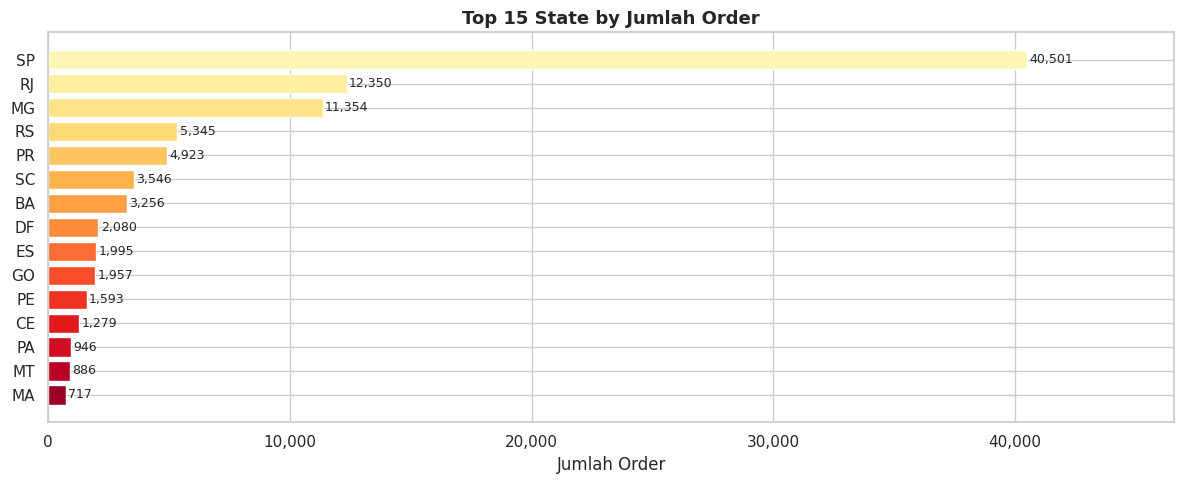

Top 5 State:
customer_state  total_orders
            SP         40501
            RJ         12350
            MG         11354
            RS          5345
            PR          4923


In [1]:
state_data = (
    orders_delivered
    .merge(customers_df[['customer_id','customer_state']], on='customer_id', how='left')
    .groupby('customer_state').agg(total_orders=('order_id','count')).reset_index()
    .sort_values('total_orders', ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 5))
top_st = state_data.head(15)
clrs = sns.color_palette('YlOrRd', len(top_st))[::-1]
ax.barh(top_st['customer_state'][::-1], top_st['total_orders'][::-1], color=clrs)
ax.set_title('Top 15 State by Jumlah Order', fontweight='bold', fontsize=13)
ax.set_xlabel('Jumlah Order')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, val in enumerate(top_st['total_orders'][::-1]):
    ax.text(val+100, i, f'{val:,}', va='center', fontsize=9)
ax.set_xlim(0, top_st['total_orders'].max()*1.15)
plt.tight_layout(); plt.show()
print('Top 5 State:')
print(state_data.head(5).to_string(index=False))

## Conclusion

- **Conclusion pertanyaan 1:** Kategori **health_beauty** menghasilkan total revenue tertinggi (~R$1.23 juta) sepanjang 2017–2018, diikuti **watches_gifts** dan **bed_bath_table**. Top 10 dari 70+ kategori menyumbang >55% total pendapatan. Rekomendasi: fokuskan investasi stok dan kampanye marketing pada 10 kategori teratas untuk memaksimalkan ROI.

- **Conclusion pertanyaan 2:** Terdapat korelasi negatif signifikan antara keterlambatan dan kepuasan pelanggan. Order tepat waktu mendapat avg score 4.29, sementara yang terlambat >15 hari hanya ~1.8. Sekitar 6.8% order masih terlambat. Rekomendasi: jadikan SLA pengiriman sebagai KPI utama logistik karena berdampak langsung pada reputasi platform.